# Predicting F1 Pit Stops

Link to Competittion: https://www.kaggle.com/competitions/playground-series-s6ee/overview

## Imports

In [38]:
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['figure.figsize'] = (12, 6)

import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)

import xgboost as xgb

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import auc, accuracy_score, confusion_matrix, mean_squared_error, classification_report
from sklearn.model_selection import cross_val_score, GridSearchCV, KFold, RandomizedSearchCV, train_test_split
from sklearn.cluster import KMeans

from common import *

In [39]:
from platform import python_version
print('python: ', python_version())
print('pandas: ', pd.__version__)
print('numpy: ', np.__version__)
import matplotlib
print('matplotlib: ', matplotlib.__version__)
print('seaborn: ', sns.__version__)
import sklearn
print('sklearn: ', sklearn.__version__)
print('xgboost: ', xgb.__version__)

python:  3.13.11
pandas:  2.3.3
numpy:  2.3.5
matplotlib:  3.10.8
seaborn:  0.13.2
sklearn:  1.8.0
xgboost:  3.2.0


## Helpers

## Load data

In [40]:
train_df = pd.read_csv('archive/train.csv')
test_df = pd.read_csv('archive/test.csv')
orig_df = pd.read_csv('archive/f1_strategy_dataset_v4.csv')

In [41]:
train_df

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439135,439135,D755,MEDIUM,Miami Grand Prix,2023,0,49,2,8.0,17,92.638,-0.076,-15.859,0.859649,0.0,0.0
439136,439136,D731,MEDIUM,Miami Grand Prix,2023,0,49,2,5.0,1,85.890,-0.083,-4.907,0.859649,0.0,0.0
439137,439137,D716,MEDIUM,Miami Grand Prix,2023,0,49,2,18.0,1,91.644,-0.182,-56.371,0.942308,0.0,0.0
439138,439138,D665,HARD,Abu Dhabi Grand Prix,2023,0,48,3,10.0,1,89.947,-0.001,-20.721,0.827586,1.0,0.0


In [42]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

In [43]:
train_df['PitNextLap'].value_counts()

PitNextLap
0.0    351759
1.0     87381
Name: count, dtype: int64

In [44]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188165 entries, 0 to 188164
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      188165 non-null  int64  
 1   Driver                  188165 non-null  object 
 2   Compound                188165 non-null  object 
 3   Race                    188165 non-null  object 
 4   Year                    188165 non-null  int64  
 5   PitStop                 188165 non-null  int64  
 6   LapNumber               188165 non-null  int64  
 7   Stint                   188165 non-null  int64  
 8   TyreLife                188165 non-null  float64
 9   Position                188165 non-null  int64  
 10  LapTime (s)             188165 non-null  float64
 11  LapTime_Delta           188165 non-null  float64
 12  Cumulative_Degradation  188165 non-null  float64
 13  RaceProgress            188165 non-null  float64
 14  Position_Change     

### Look for NaN values

In [45]:
train_df.isnull().sum() 

id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64

### Look for duplicates

In [46]:
train_df.duplicated().sum()

np.int64(0)

## Call the pipeline

In [47]:
df = (train_df
          .pipe(copy_data)
          .pipe(clean_data)
          # .pipe(remove_outliers)
          .pipe(remove_duplicates)
          .pipe(make_new_features)
           )

## Features

In [48]:
target = get_target()

In [49]:
features = get_features(df)

In [50]:
features

['driver',
 'compound',
 'race',
 'year',
 'pitstop',
 'lapnumber',
 'stint',
 'tyrelife',
 'position',
 'laptime_(s)',
 'laptime_delta',
 'cumulative_degradation',
 'raceprogress',
 'position_change']

In [51]:
categorical_features = [
    'driver',
    'compound',
    'race'
]

In [52]:
numerical_features = [f for f in features if f not in categorical_features]

In [53]:
categorical_features

['driver', 'compound', 'race']

In [54]:
numerical_features

['year',
 'pitstop',
 'lapnumber',
 'stint',
 'tyrelife',
 'position',
 'laptime_(s)',
 'laptime_delta',
 'cumulative_degradation',
 'raceprogress',
 'position_change']

In [55]:
df[features]

,driver,compound,race,year,pitstop,lapnumber,stint,tyrelife,position,laptime_(s),laptime_delta,cumulative_degradation,raceprogress,position_change
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439135,D755,MEDIUM,Miami Grand Prix,2023,0,49,2,8.0,17,92.638,-0.076,-15.859,0.859649,0.0
439136,D731,MEDIUM,Miami Grand Prix,2023,0,49,2,5.0,1,85.890,-0.083,-4.907,0.859649,0.0
439137,D716,MEDIUM,Miami Grand Prix,2023,0,49,2,18.0,1,91.644,-0.182,-56.371,0.942308,0.0
439138,D665,HARD,Abu Dhabi Grand Prix,2023,0,48,3,10.0,1,89.947,-0.001,-20.721,0.827586,1.0


In [56]:
# df = pd.get_dummies(df[features], dtype='int')

In [57]:
# df[target] = train_df['PitNextLap']

In [58]:
df[target].value_counts()

pitnextlap
0.0    351759
1.0     87381
Name: count, dtype: int64

### Look at column types

In [59]:
df

,driver,compound,race,year,pitstop,lapnumber,stint,tyrelife,position,laptime_(s),laptime_delta,cumulative_degradation,raceprogress,position_change,pitnextlap
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439135,D755,MEDIUM,Miami Grand Prix,2023,0,49,2,8.0,17,92.638,-0.076,-15.859,0.859649,0.0,0.0
439136,D731,MEDIUM,Miami Grand Prix,2023,0,49,2,5.0,1,85.890,-0.083,-4.907,0.859649,0.0,0.0
439137,D716,MEDIUM,Miami Grand Prix,2023,0,49,2,18.0,1,91.644,-0.182,-56.371,0.942308,0.0,0.0
439138,D665,HARD,Abu Dhabi Grand Prix,2023,0,48,3,10.0,1,89.947,-0.001,-20.721,0.827586,1.0,0.0


## Describe

In [60]:
df.describe()

,year,pitstop,lapnumber,stint,tyrelife,position,laptime_(s),laptime_delta,cumulative_degradation,raceprogress,position_change,pitnextlap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


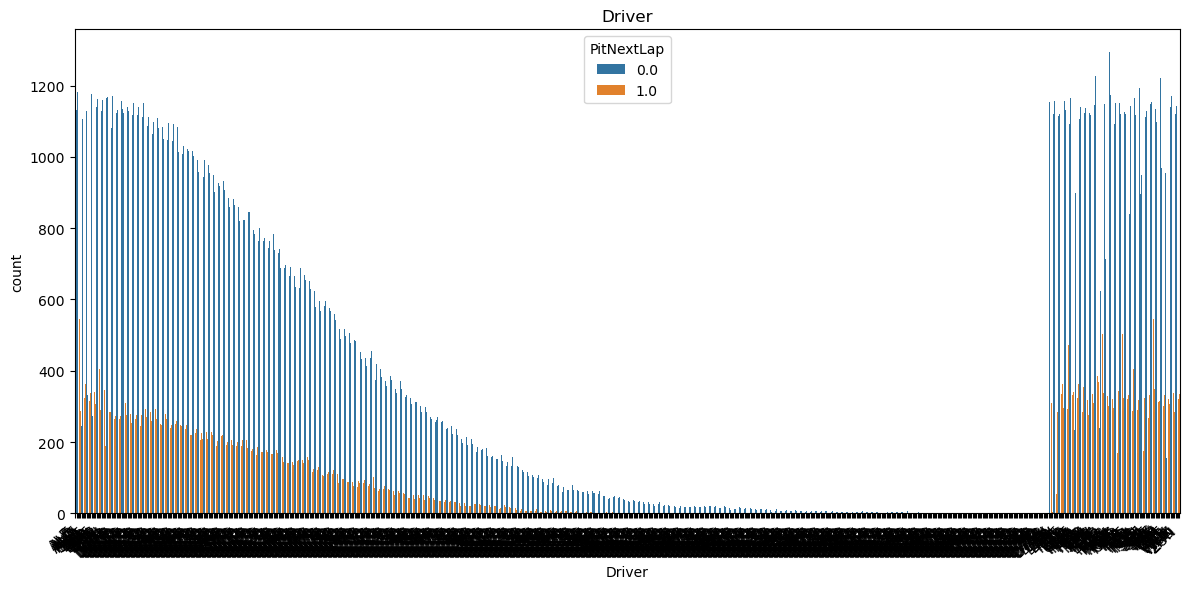

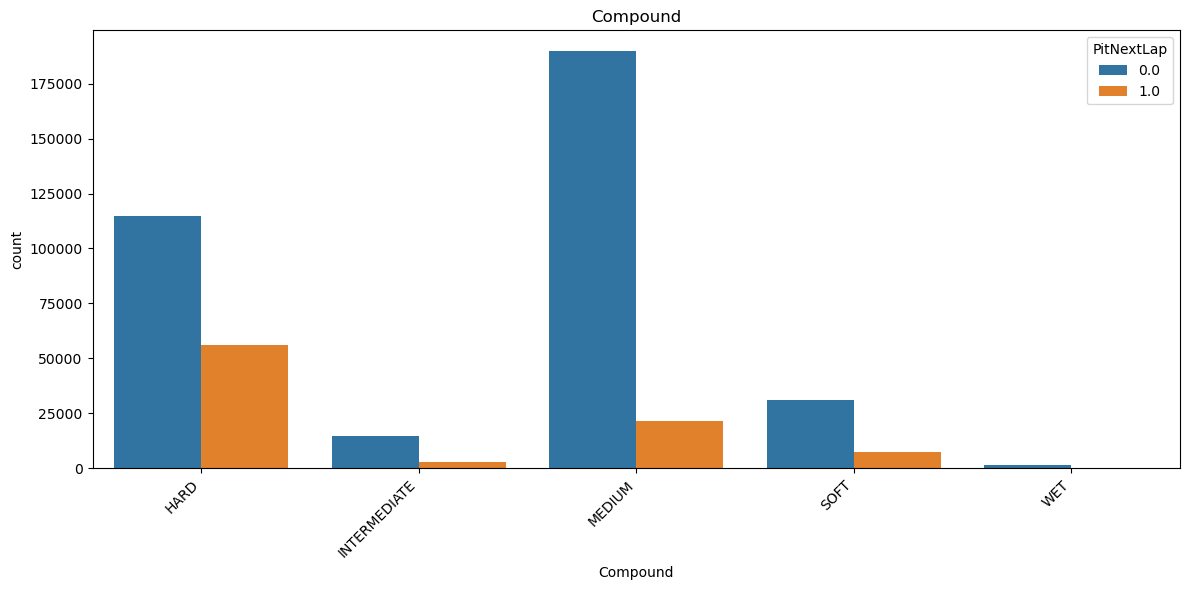

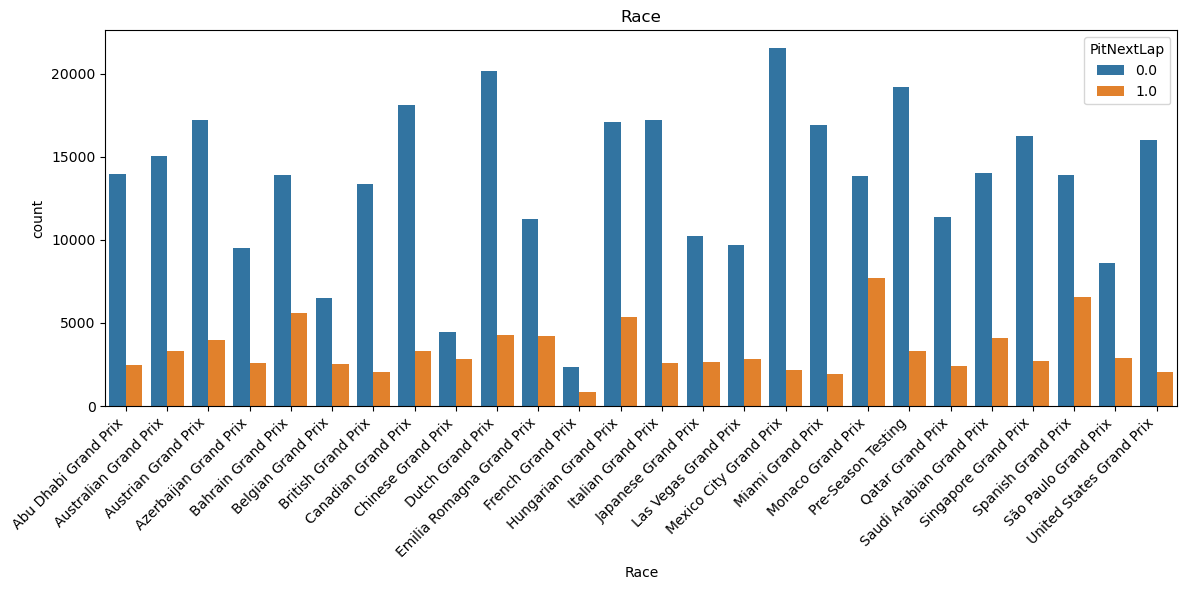

In [61]:
# Value counts for each categorical column, split by Churn
churn_col = 'PitNextLap' if 'PitNextLap' in train_df.columns else 'pitnextlap'
for f in train_df.select_dtypes(include=['object']).columns:
    if f == churn_col:
        continue
    plot_df = train_df.groupby([f, churn_col]).size().reset_index(name='count')
    sns.barplot(data=plot_df, x=f, y='count', hue=churn_col)
    plt.title(f)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Distributions (train vs test)

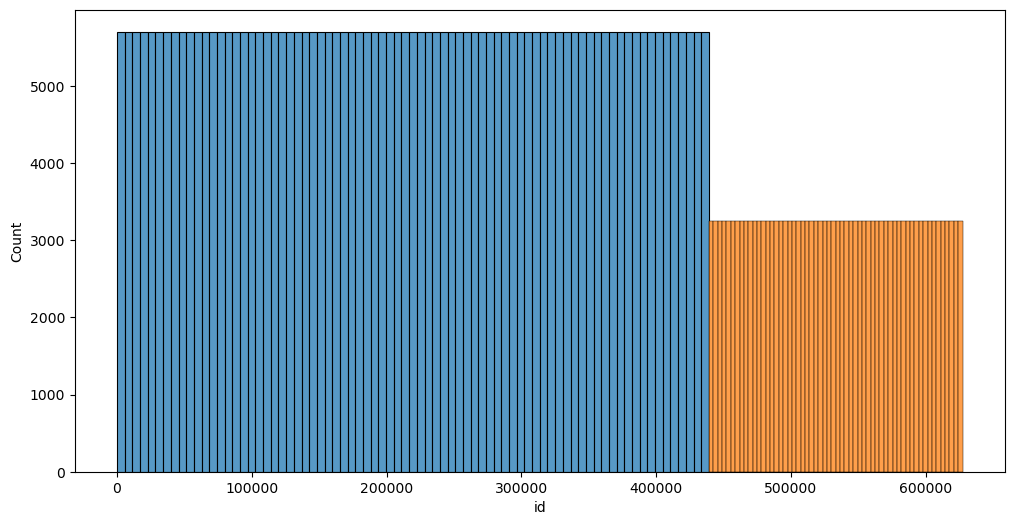

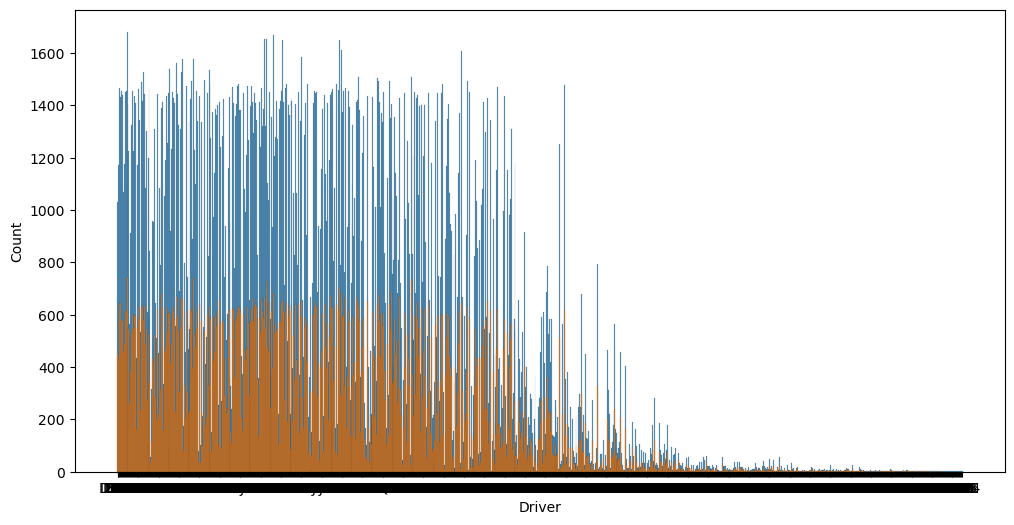

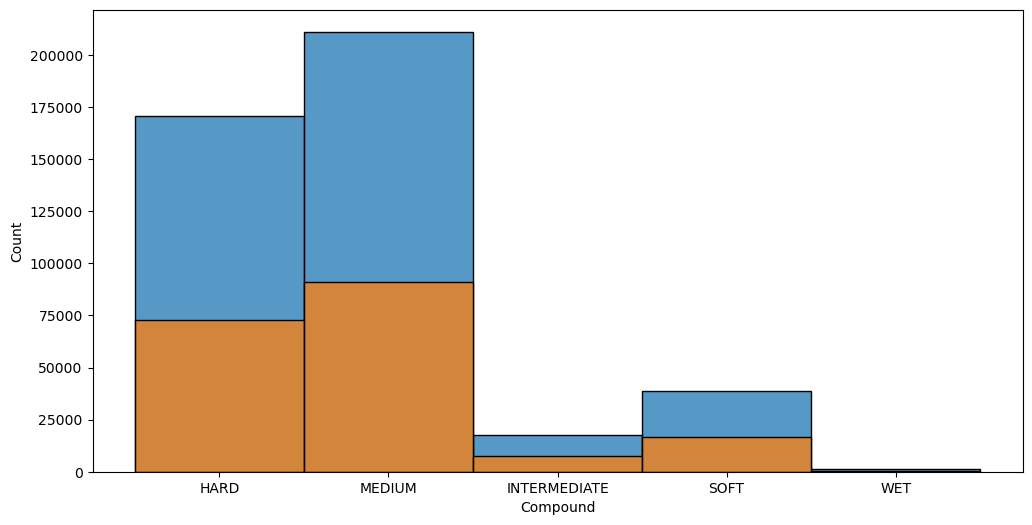

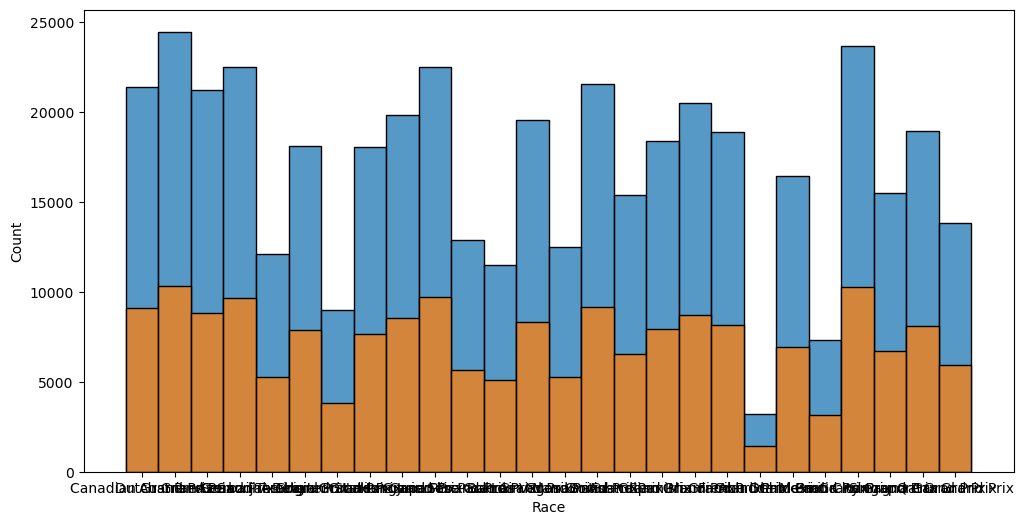

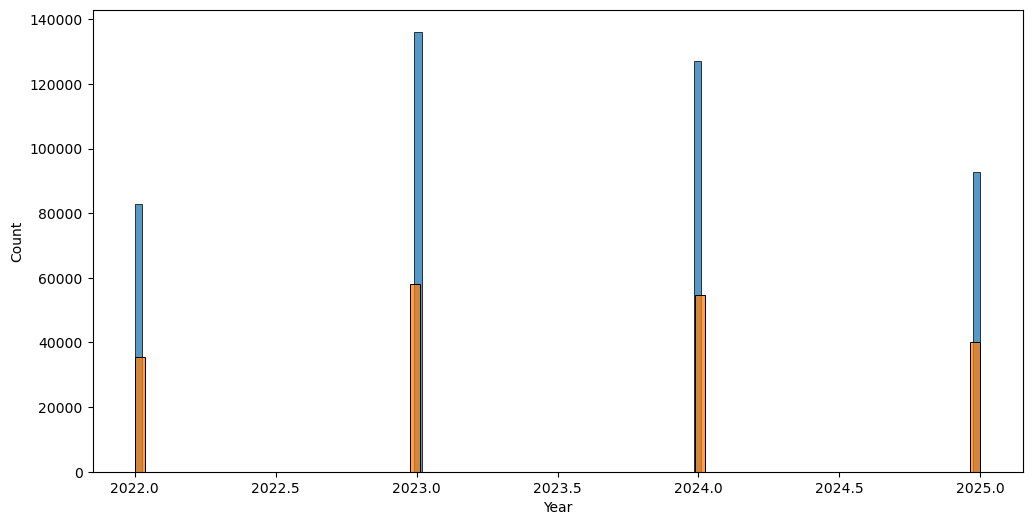

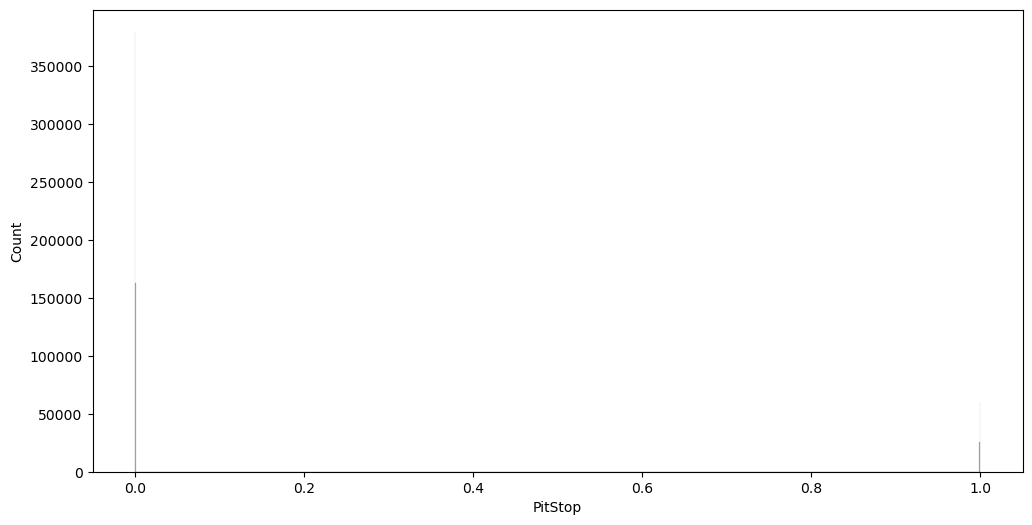

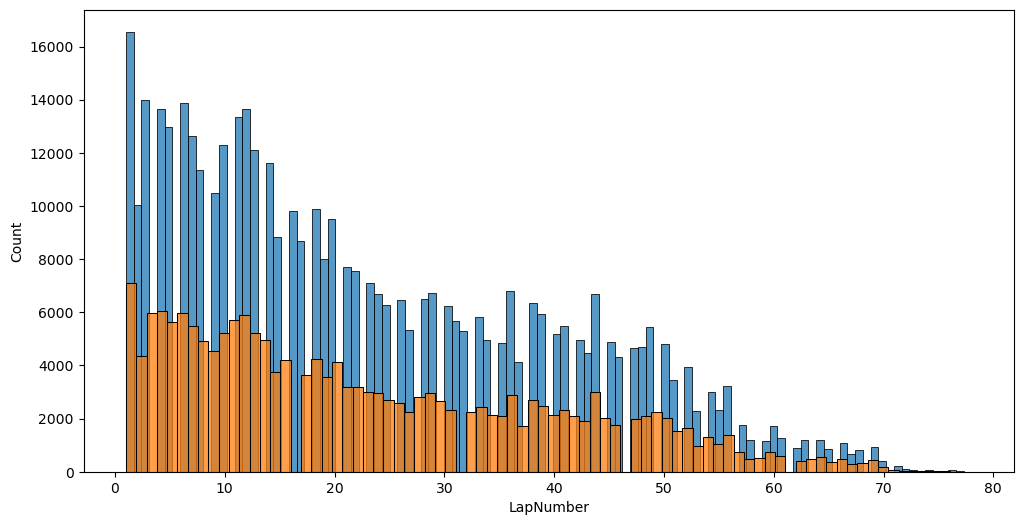

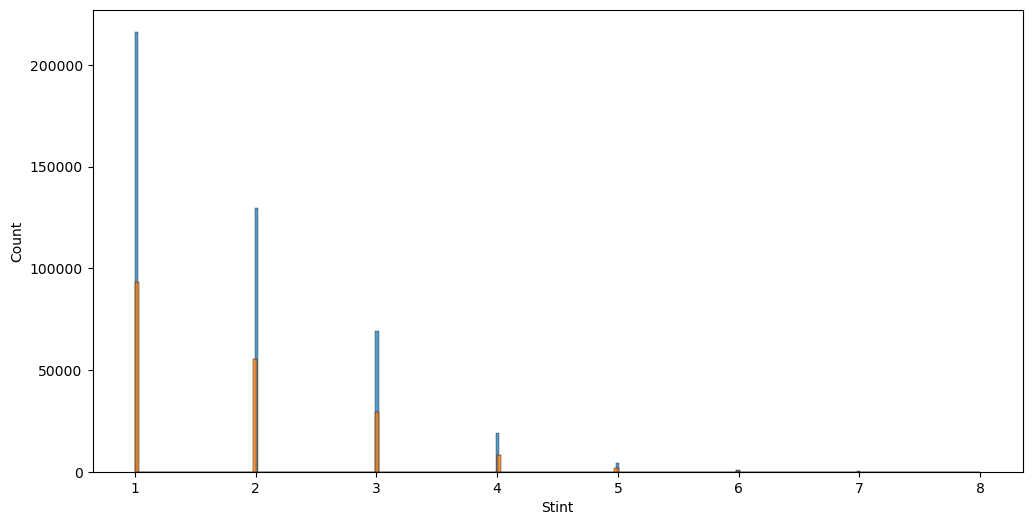

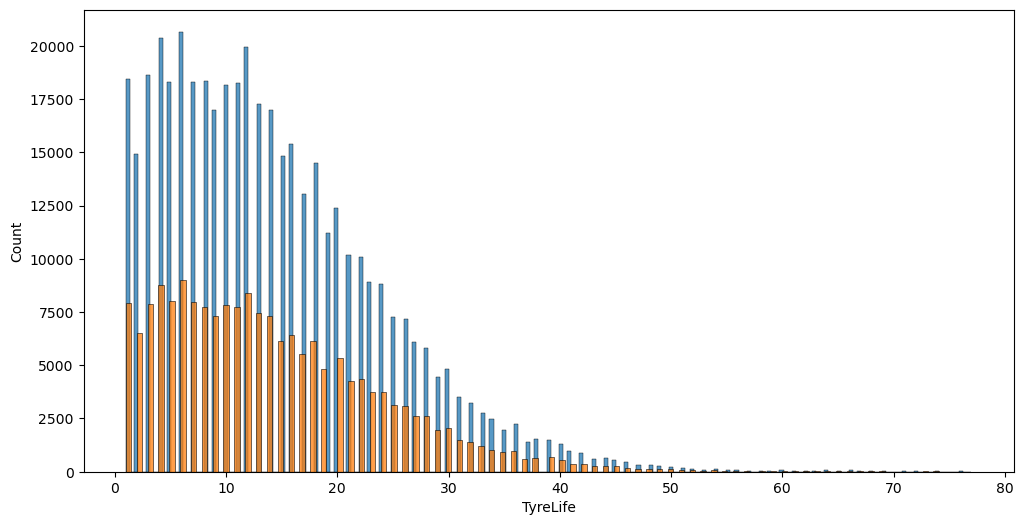

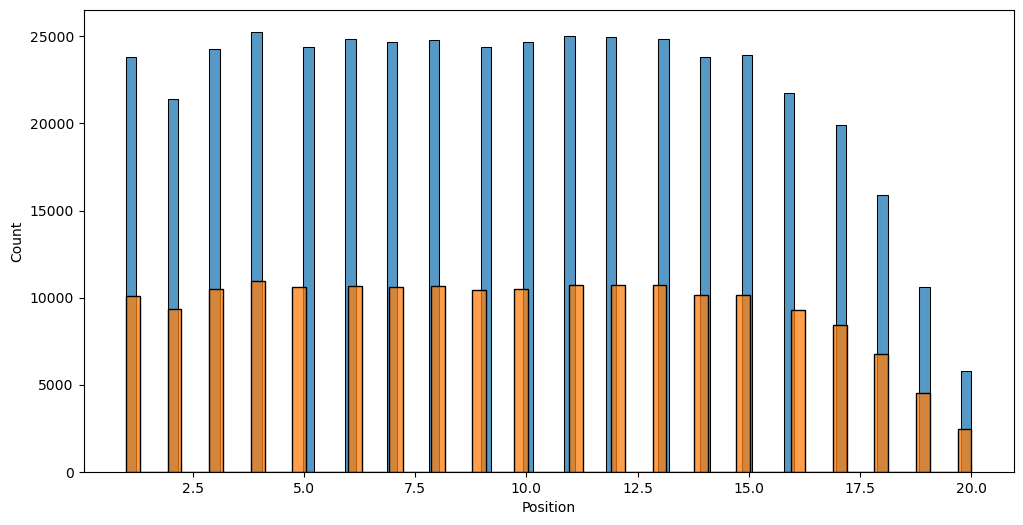

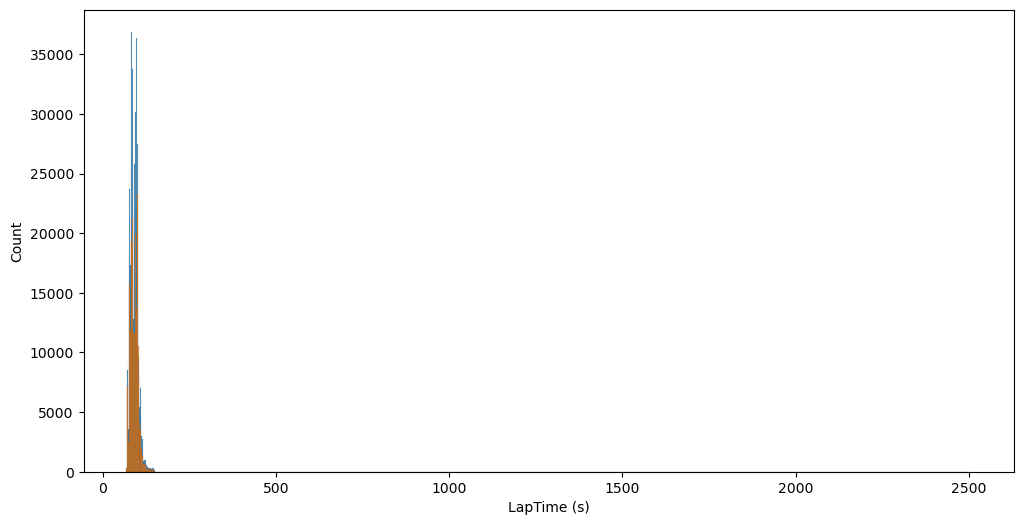

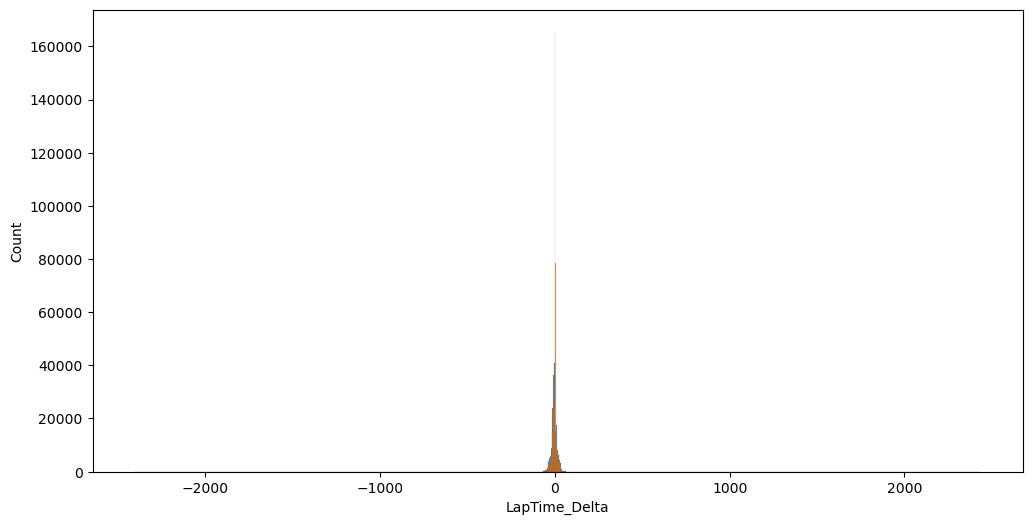

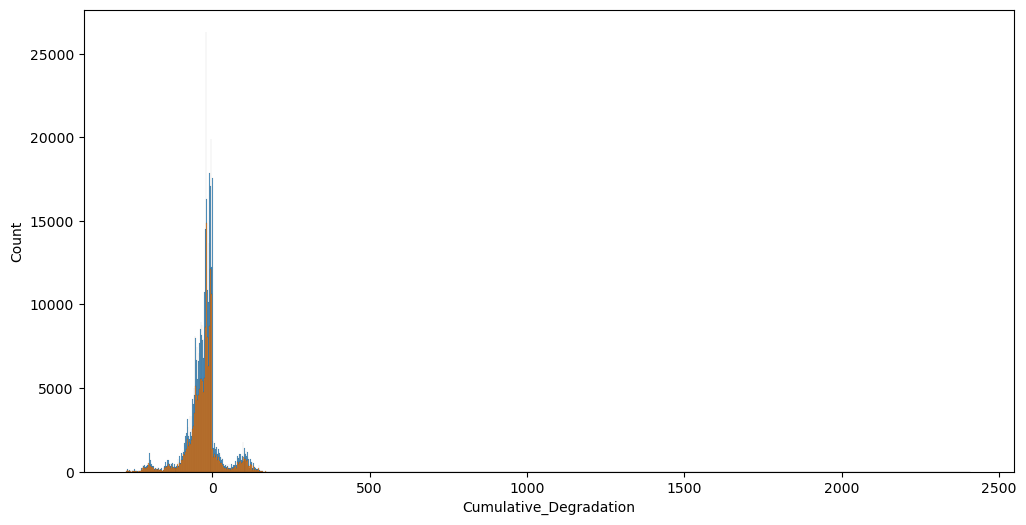

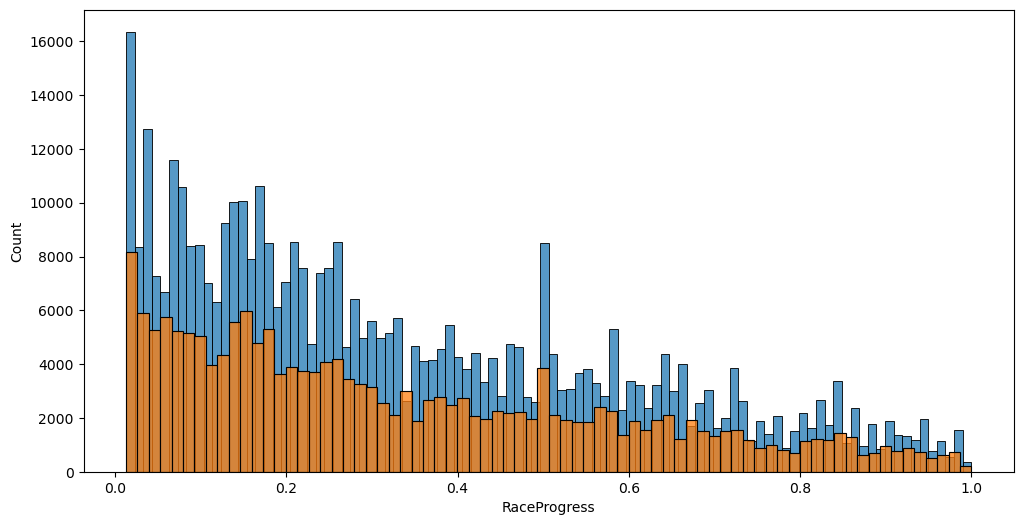

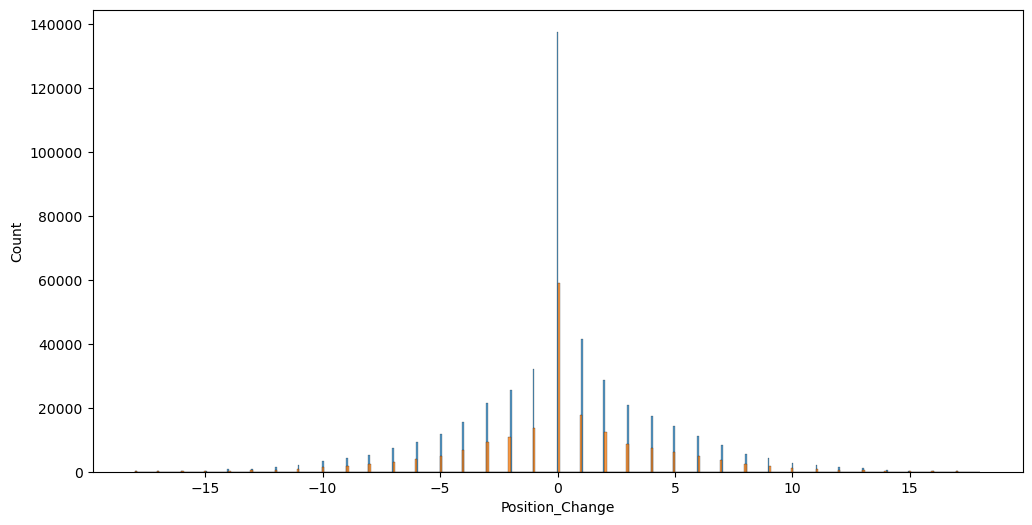

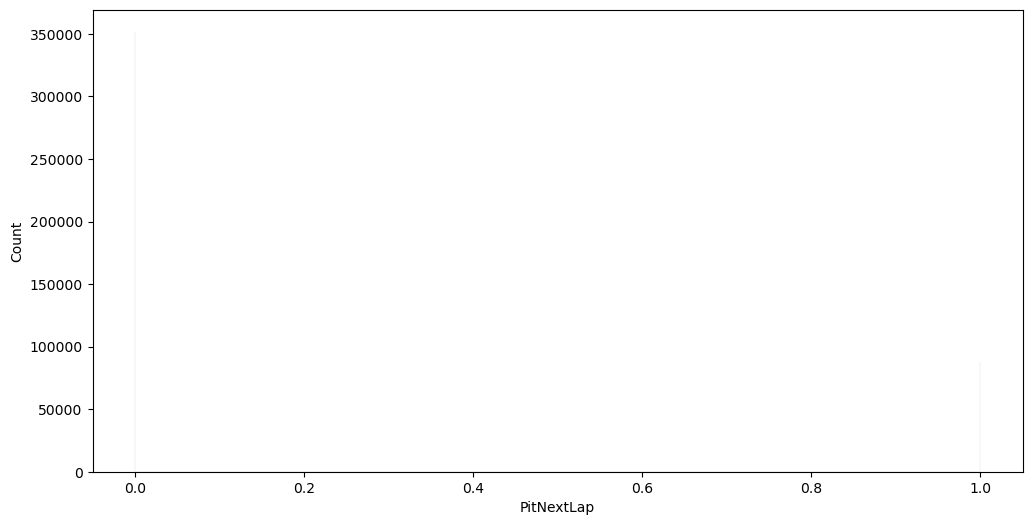

In [62]:
for col in train_df.columns:
    sns.histplot(train_df[col])
    if col in test_df.columns:
        sns.histplot(test_df[col])
    plt.show()

## Features

## Bar Charts

## Kmeans

## Scatter Plots

## Correlation Plots

In [63]:
df[target].value_counts()

pitnextlap
0.0    351759
1.0     87381
Name: count, dtype: int64

In [64]:
df

,driver,compound,race,year,pitstop,lapnumber,stint,tyrelife,position,laptime_(s),laptime_delta,cumulative_degradation,raceprogress,position_change,pitnextlap
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
439135,D755,MEDIUM,Miami Grand Prix,2023,0,49,2,8.0,17,92.638,-0.076,-15.859,0.859649,0.0,0.0
439136,D731,MEDIUM,Miami Grand Prix,2023,0,49,2,5.0,1,85.890,-0.083,-4.907,0.859649,0.0,0.0
439137,D716,MEDIUM,Miami Grand Prix,2023,0,49,2,18.0,1,91.644,-0.182,-56.371,0.942308,0.0,0.0
439138,D665,HARD,Abu Dhabi Grand Prix,2023,0,48,3,10.0,1,89.947,-0.001,-20.721,0.827586,1.0,0.0


<Axes: >

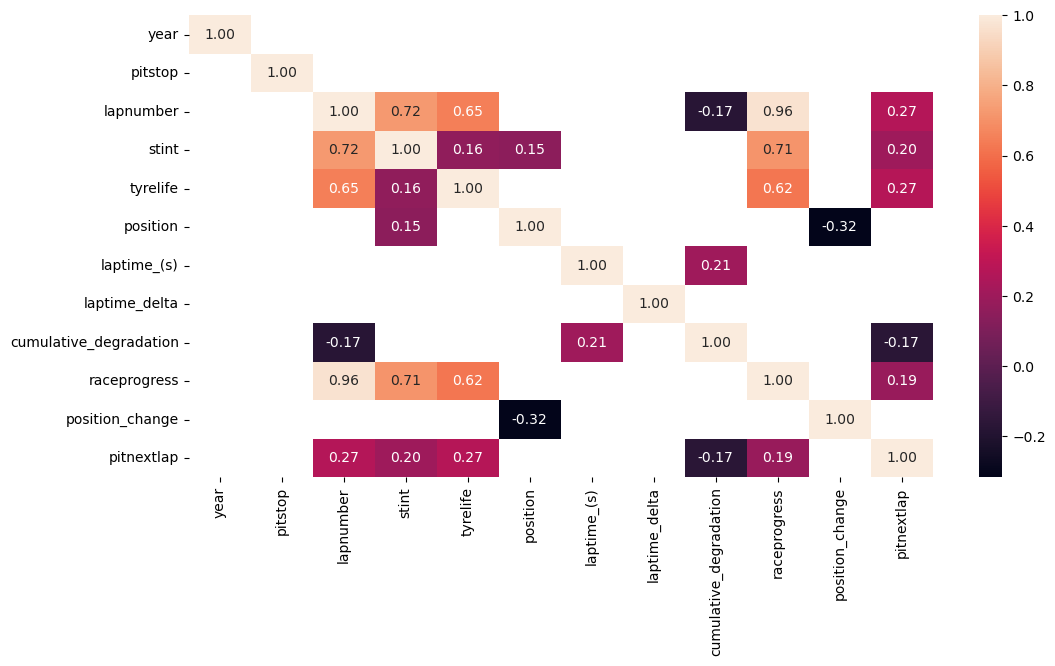

In [65]:
corr_matrix = df.corr(numeric_only=True)

mask = abs(corr_matrix) < 0.15

sns.heatmap(data=corr_matrix, mask=mask, fmt='.2f', annot=True)

<Axes: xlabel='pitnextlap'>

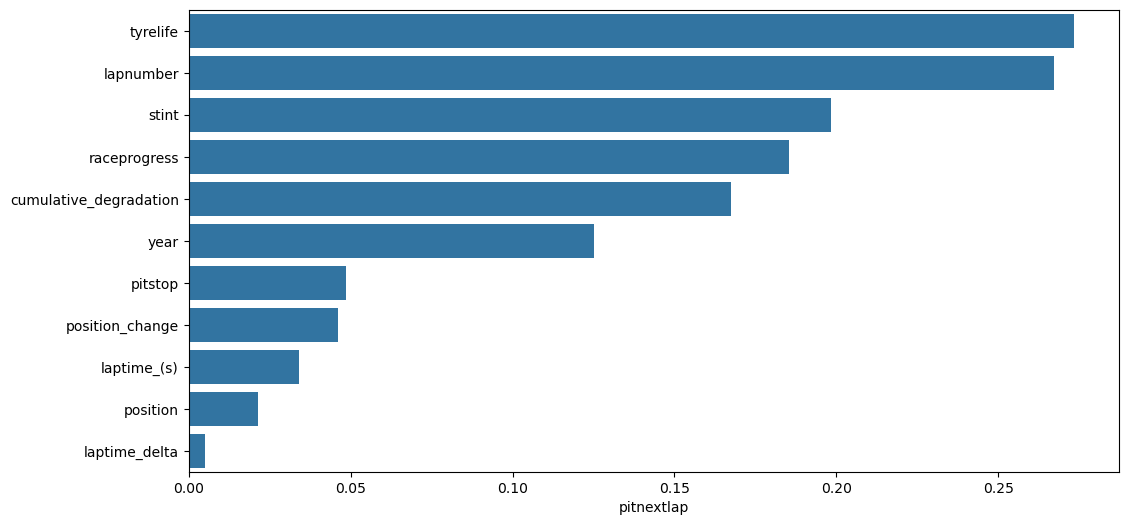

In [68]:
sns.barplot(corr_matrix[target].drop(target).abs().sort_values(ascending=False)[:15], orient='h')

In [69]:
corr_matrix[target].drop(target).abs().sort_values(ascending=False)[:15]

tyrelife                  0.273510
lapnumber                 0.267057
stint                     0.198193
raceprogress              0.185477
cumulative_degradation    0.167401
year                      0.125267
pitstop                   0.048567
position_change           0.046230
laptime_(s)               0.034096
position                  0.021348
laptime_delta             0.004946
Name: pitnextlap, dtype: float64

## original data exploration

In [32]:
orig_df['Irrigation_Need'].value_counts()

Irrigation_Need
Low       5864
Medium    3800
High       336
Name: count, dtype: int64

In [33]:
train_df.columns.to_list(), orig_df.columns.to_list()

(['id',
  'Soil_Type',
  'Soil_pH',
  'Soil_Moisture',
  'Organic_Carbon',
  'Electrical_Conductivity',
  'Temperature_C',
  'Humidity',
  'Rainfall_mm',
  'Sunlight_Hours',
  'Wind_Speed_kmh',
  'Crop_Type',
  'Crop_Growth_Stage',
  'Season',
  'Irrigation_Type',
  'Water_Source',
  'Field_Area_hectare',
  'Mulching_Used',
  'Previous_Irrigation_mm',
  'Region',
  'Irrigation_Need'],
 ['Soil_Type',
  'Soil_pH',
  'Soil_Moisture',
  'Organic_Carbon',
  'Electrical_Conductivity',
  'Temperature_C',
  'Humidity',
  'Rainfall_mm',
  'Sunlight_Hours',
  'Wind_Speed_kmh',
  'Crop_Type',
  'Crop_Growth_Stage',
  'Season',
  'Irrigation_Type',
  'Water_Source',
  'Field_Area_hectare',
  'Mulching_Used',
  'Previous_Irrigation_mm',
  'Region',
  'Irrigation_Need'])